In [ ]:
from pathlib import Path
import re
import yaml
import h5py
import numpy as np
import pandas as pd

from scipy.signal import hilbert
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import librosa
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [ ]:
H5_PATH = Path("preprocessed/madeeg_preprocessed.hdf5")
YAML_PATH = Path("preprocessed/madeeg_preprocessed.yaml")

EEG_SR = 256
AUDIO_SR = 44100
HOP_LENGTH = round(AUDIO_SR / EEG_SR)   # ~172
N_MELS = 24                             # Cantisani best MEL config
FIXED_T = 6000                          # truncate all trials to common EEG length
RIDGE_ALPHA = 1.0                       # initial proxy; Cantisani uses shrinkage regularization
RANDOM_STATE = 42

True True preprocessed/madeeg_preprocessed.hdf5 preprocessed/madeeg_preprocessed.yaml


In [59]:
def parse_stim_name(stim_name: str):
    parts = stim_name.split("_")

    genre = parts[0]
    piece = parts[1]
    ensemble = parts[2]                 # duo / trio / solo
    instr_block = parts[3]              # e.g. CoFl / CoOb / CoFlOb
    theme = parts[4]                    # theme1 / theme2
    spatial = parts[5]                  # mono / stereo
    target = parts[6] if len(parts) > 6 else None

    instruments = re.findall(r"[A-Z][a-z]?", instr_block)

    return {
        "genre": genre,
        "piece": piece,
        "ensemble": ensemble,
        "instr_block": instr_block,
        "theme": theme,
        "spatial": spatial,
        "target": target,
        "instruments": instruments,
    }

In [60]:
with open(YAML_PATH, "r") as f:
    yaml_meta = yaml.safe_load(f)

type(yaml_meta), list(yaml_meta.keys())[:10] if isinstance(yaml_meta, dict) else None

(dict, ['0001', '0002', '0003', '0004', '0005', '0007', '0008', '0009'])

In [63]:
trials = []

with h5py.File(H5_PATH, "r") as h5:
    subjects = sorted(list(h5.keys()))

    for subj in subjects:
        for stim_name in h5[subj].keys():
            g = h5[subj][stim_name]

            if not all(k in g for k in ["response", "soli", "stimulus"]):
                continue

            parsed = parse_stim_name(stim_name)

            response_shape = tuple(g["response"].shape)
            soli_shape = tuple(g["soli"].shape)
            stimulus_shape = tuple(g["stimulus"].shape)

            trials.append({
                "subject": subj,
                "stim_name": stim_name,
                "genre": parsed["genre"],
                "piece": parsed["piece"],
                "ensemble": parsed["ensemble"],
                "theme": parsed["theme"],
                "spatial": parsed["spatial"],
                "target": parsed["target"],
                "instruments": parsed["instruments"],
                "n_instruments": len(parsed["instruments"]),
                "response_shape": response_shape,
                "soli_shape": soli_shape,
                "stimulus_shape": stimulus_shape,
                "fs_eeg": EEG_SR,
                "fs_audio": AUDIO_SR,
            })

df = pd.DataFrame(trials)
print(df.shape)
display(df.head())
print(df["ensemble"].value_counts())
print(df["subject"].value_counts().sort_index())

(246, 15)


,subject,stim_name,genre,piece,ensemble,theme,spatial,target,instruments,n_instruments,response_shape,soli_shape,stimulus_shape,fs_eeg,fs_audio
0,0001,classique_morceau1_duo_CoFl_theme1_stereo_Co,classique,morceau1,duo,theme1,stereo,Co,"[Co, Fl]",2,"(20, 7172)","(3, 1235312)","(2, 1235312)",256,44100
1,0001,classique_morceau1_duo_CoFl_theme1_stereo_Fl,classique,morceau1,duo,theme1,stereo,Fl,"[Co, Fl]",2,"(20, 7172)","(3, 1235312)","(2, 1235312)",256,44100
2,0001,classique_morceau1_duo_CoOb_theme1_stereo_Co,classique,morceau1,duo,theme1,stereo,Co,"[Co, Ob]",2,"(20, 7172)","(3, 1235312)","(2, 1235312)",256,44100
3,0001,classique_morceau1_duo_CoOb_theme2_stereo_Ob,classique,morceau1,duo,theme2,stereo,Ob,"[Co, Ob]",2,"(20, 6148)","(3, 1058916)","(2, 1058916)",256,44100
4,0001,classique_morceau1_duo_FlOb_theme1_stereo_Fl,classique,morceau1,duo,theme1,stereo,Fl,"[Fl, Ob]",2,"(20, 7172)","(3, 1235312)","(2, 1235312)",256,44100


ensemble
duo     154
trio     92
Name: count, dtype: int64
subject
0001    32
0002    32
0003    32
0004    32
0005    32
0007    22
0008    32
0009    32
Name: count, dtype: int64


In [64]:
assert len(df) > 0, "Empty dataframe"
assert df["ensemble"].isin(["duo", "trio"]).all(), "Unexpected ensemble labels"
assert df["target"].notna().all(), "Missing target labels"

print("Unique subjects:", sorted(df["subject"].unique()))
print("Unique targets:", sorted(df["target"].unique()))
print("Unique genres:", sorted(df["genre"].unique()))

Unique subjects: ['0001', '0002', '0003', '0004', '0005', '0007', '0008', '0009']
Unique targets: ['Bo', 'Bs', 'Co', 'Dr', 'Fh', 'Fl', 'Gt', 'Ob', 'Vx']
Unique genres: ['classique', 'pop']


In [65]:
def extract_trial_arrays(h5, subject, stim_name, fixed_t=FIXED_T):
    g = h5[subject][stim_name]

    eeg = np.array(g["response"])              # (channels, time)
    soli = np.array(g["soli"])                 # (n_sources, audio_samples)
    mixture = np.array(g["stimulus"])          # (n_channels_mix, audio_samples) or similar

    eeg = eeg[:, :fixed_t]

    audio_t = fixed_t * HOP_LENGTH
    soli = soli[:, :audio_t]
    mixture = mixture[:, :audio_t]

    return eeg, soli, mixture

In [66]:
def get_target_index(row):
    instruments = row["instruments"]
    target = row["target"]
    assert target in instruments, f"Target {target} not in instruments {instruments}"
    return instruments.index(target)

df["target_idx"] = df.apply(get_target_index, axis=1)
df[["stim_name", "instruments", "target", "target_idx"]].head()

,stim_name,instruments,target,target_idx
0,classique_morceau1_duo_CoFl_theme1_stereo_Co,"[Co, Fl]",Co,0
1,classique_morceau1_duo_CoFl_theme1_stereo_Fl,"[Co, Fl]",Fl,1
2,classique_morceau1_duo_CoOb_theme1_stereo_Co,"[Co, Ob]",Co,0
3,classique_morceau1_duo_CoOb_theme2_stereo_Ob,"[Co, Ob]",Ob,1
4,classique_morceau1_duo_FlOb_theme1_stereo_Fl,"[Fl, Ob]",Fl,0


In [68]:
MAX_LAG_MS = 250
MAX_LAG = int(EEG_SR * MAX_LAG_MS / 1000)

def zscore(x, axis=0, eps=1e-8):
    m = np.mean(x, axis=axis, keepdims=True)
    s = np.std(x, axis=axis, keepdims=True)
    return (x - m) / (s + eps)

def build_lag_matrix(eeg_tc, max_lag=MAX_LAG):
    # eeg_tc: (T, C)
    T, C = eeg_tc.shape
    cols = []
    for lag in range(max_lag + 1):
        cols.append(eeg_tc[max_lag - lag:T - lag, :])
    X = np.concatenate(cols, axis=1)
    return X  # (T-max_lag, C*(max_lag+1))

In [69]:
def audio_to_mel_features(audio_1d, sr=AUDIO_SR, hop_length=HOP_LENGTH, n_mels=N_MELS):
    mel = librosa.feature.melspectrogram(
        y=audio_1d.astype(np.float32),
        sr=sr,
        n_fft=hop_length * 2,
        hop_length=hop_length,
        n_mels=n_mels,
        power=1.0,
        center=False,
    ).T
    return zscore(mel, axis=0)

In [70]:
def build_supervised_sample(h5, row):
    eeg, soli, mixture = extract_trial_arrays(h5, row.subject, row.stim_name, fixed_t=FIXED_T)

    target_idx = row.target_idx
    target_audio = soli[target_idx]

    eeg_tc = zscore(eeg.T, axis=0)                 # (T, C)
    mel = audio_to_mel_features(target_audio)      # (T_mel, F)

    T = min(len(eeg_tc), len(mel))
    eeg_tc = eeg_tc[:T]
    mel = mel[:T]

    X = build_lag_matrix(eeg_tc, max_lag=MAX_LAG)
    Y = mel[MAX_LAG:]

    T2 = min(len(X), len(Y))
    return X[:T2], Y[:T2]

In [71]:
X_list, Y_list, meta_rows = [], [], []

with h5py.File(H5_PATH, "r") as h5:
    for _, row in df.iterrows():
        X_i, Y_i = build_supervised_sample(h5, row)
        X_list.append(X_i)
        Y_list.append(Y_i)
        meta_rows.append({
            "subject": row.subject,
            "stim_name": row.stim_name,
            "ensemble": row.ensemble,
            "genre": row.genre,
            "target": row.target,
            "n_frames": len(X_i),
        })

meta_df = pd.DataFrame(meta_rows)

print("N trials prepared:", len(X_list))
print("Example X shape:", X_list[0].shape)
print("Example Y shape:", Y_list[0].shape)
display(meta_df.head())

N trials prepared: 246
Example X shape: (5935, 1300)
Example Y shape: (5935, 24)


,subject,stim_name,ensemble,genre,target,n_frames
0,0001,classique_morceau1_duo_CoFl_theme1_stereo_Co,duo,classique,Co,5935
1,0001,classique_morceau1_duo_CoFl_theme1_stereo_Fl,duo,classique,Fl,5935
2,0001,classique_morceau1_duo_CoOb_theme1_stereo_Co,duo,classique,Co,5935
3,0001,classique_morceau1_duo_CoOb_theme2_stereo_Ob,duo,classique,Ob,5935
4,0001,classique_morceau1_duo_FlOb_theme1_stereo_Fl,duo,classique,Fl,5935


In [72]:
def fit_ridge_decoder(X_train, Y_train, alpha=RIDGE_ALPHA):
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    Xn = scaler_x.fit_transform(X_train)
    Yn = scaler_y.fit_transform(Y_train)

    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(Xn, Yn)

    return model, scaler_x, scaler_y

def predict_decoder(model, scaler_x, scaler_y, X):
    Xn = scaler_x.transform(X)
    Yp = model.predict(Xn)
    return scaler_y.inverse_transform(Yp)

In [73]:
results = []

with h5py.File(H5_PATH, "r") as h5:
    for subject in sorted(df["subject"].unique()):
        df_sub = df[df["subject"] == subject].reset_index(drop=True)

        for test_idx in range(len(df_sub)):
            test_row = df_sub.iloc[test_idx]
            train_rows = df_sub.drop(index=test_idx)

            X_train_all, Y_train_all = [], []
            for _, row in train_rows.iterrows():
                X_i, Y_i = build_supervised_sample(h5, row)
                X_train_all.append(X_i)
                Y_train_all.append(Y_i)

            X_train = np.concatenate(X_train_all, axis=0)
            Y_train = np.concatenate(Y_train_all, axis=0)

            model, scaler_x, scaler_y = fit_ridge_decoder(X_train, Y_train, alpha=RIDGE_ALPHA)

            X_test, Y_test = build_supervised_sample(h5, test_row)
            Y_pred = predict_decoder(model, scaler_x, scaler_y, X_test)

            corrs = [pearsonr(Y_pred[:, j], Y_test[:, j])[0] for j in range(Y_test.shape[1])]
            mean_corr = float(np.nanmean(corrs))

            results.append({
                "subject": subject,
                "stim_name": test_row.stim_name,
                "ensemble": test_row.ensemble,
                "genre": test_row.genre,
                "target": test_row.target,
                "mean_pearson": mean_corr
            })

results_df = pd.DataFrame(results)
print(results_df.shape)
display(results_df.head())

(246, 6)


,subject,stim_name,ensemble,genre,target,mean_pearson
0,0001,classique_morceau1_duo_CoFl_theme1_stereo_Co,duo,classique,Co,0.018149
1,0001,classique_morceau1_duo_CoFl_theme1_stereo_Fl,duo,classique,Fl,-0.019932
2,0001,classique_morceau1_duo_CoOb_theme1_stereo_Co,duo,classique,Co,0.025955
3,0001,classique_morceau1_duo_CoOb_theme2_stereo_Ob,duo,classique,Ob,0.008799
4,0001,classique_morceau1_duo_FlOb_theme1_stereo_Fl,duo,classique,Fl,-0.010057


In [74]:
print("Overall mean Pearson:", results_df["mean_pearson"].mean())
print("Overall std Pearson:", results_df["mean_pearson"].std())

display(results_df.groupby("ensemble")["mean_pearson"].agg(["mean", "std", "count"]))
display(results_df.groupby("genre")["mean_pearson"].agg(["mean", "std", "count"]))
display(results_df.groupby("target")["mean_pearson"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False))

Overall mean Pearson: 0.006371240025957113
Overall std Pearson: 0.029227514723671015


,mean,std,count
ensemble,,,
duo,0.008493,0.029738,154
trio,0.002820,0.028154,92


,mean,std,count
genre,,,
classique,0.003476,0.027776,141
pop,0.010259,0.030777,105


,mean,std,count
target,,,
Dr,0.016435,0.025217,31
Gt,0.015529,0.033745,23
Bs,0.008387,0.023908,21
Co,0.008084,0.024298,24
Ob,0.005603,0.025315,24
Fl,0.005523,0.026646,48
Bo,0.001205,0.028010,23
Vx,0.001148,0.036468,30
Fh,-0.005966,0.035294,22


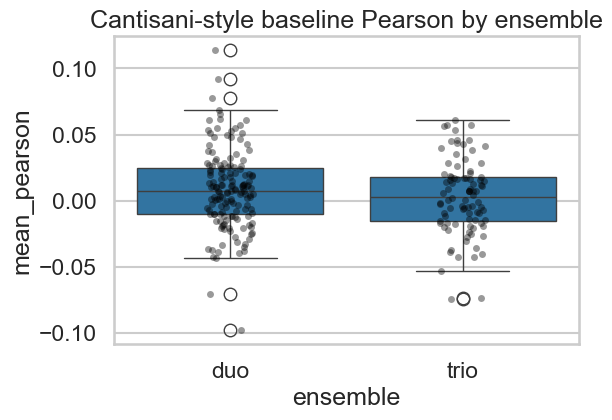

In [75]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=results_df, x="ensemble", y="mean_pearson")
sns.stripplot(data=results_df, x="ensemble", y="mean_pearson", color="black", alpha=0.4)
plt.title("Cantisani-style baseline Pearson by ensemble")
plt.show()

In [76]:
results_df.to_csv("cantisani_style_baseline_results.csv", index=False)
df.to_csv("trials_metadata.csv", index=False)